Code and Data Preprocessing by Dautrevaux Cyprien and Matthieu Gilson

Data from Garrido et al. J Neurophysiol 2009 (doi:10.1152/jn.90291.2008)
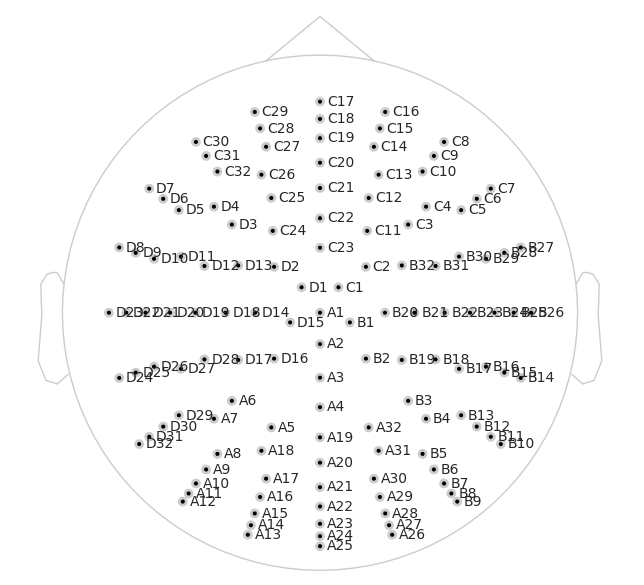

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       150000 non-null  float64
 1   1       150000 non-null  float64
 2   2       150000 non-null  float64
 3   3       150000 non-null  float64
 4   4       150000 non-null  float64
 5   5       150000 non-null  float64
 6   6       150000 non-null  float64
 7   7       150000 non-null  float64
 8   8       150000 non-null  float64
 9   9       150000 non-null  float64
 10  10      150000 non-null  float64
 11  11      150000 non-null  float64
 12  12      150000 non-null  float64
 13  13      150000 non-null  float64
 14  14      150000 non-null  float64
 15  15      150000 non-null  float64
dtypes: float64(16)
memory usage: 18.3 MB


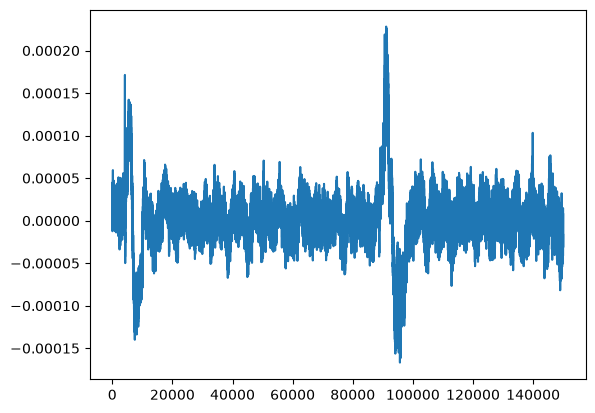

In [2]:
# get data from csv file
df = pd.read_csv('EEG_ses.csv', sep='\t', header=None)

df.info()

# example trace
plt.plot(df[7])

In [3]:
# sampling rate is 512 Hz
vt = np.arange(df.index.size) / 512.0 # in s

Text(0.5, 0, 'time (s)')

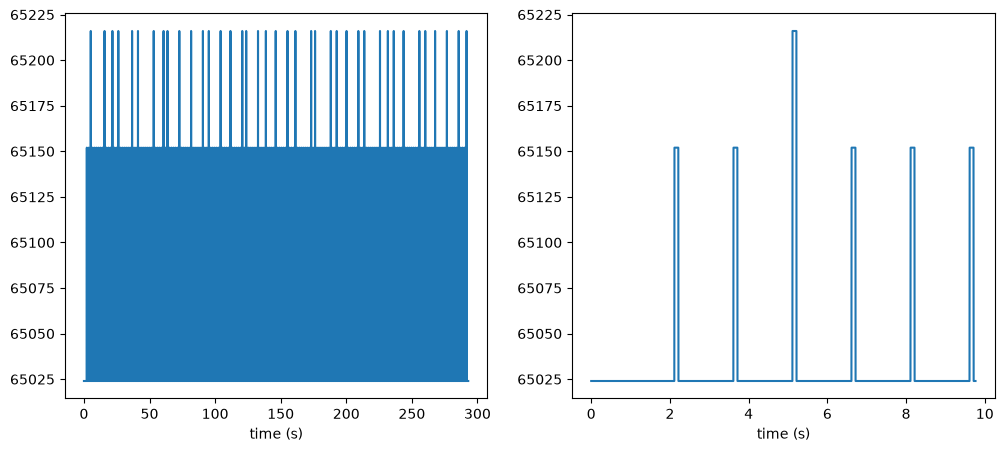

In [4]:
ts_stim = df[11]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].plot(vt, ts_stim)
axs[0].set_xlabel('time (s)')
axs[1].plot(vt[:5000], ts_stim[:5000])
axs[1].set_xlabel('time (s)')

194 194


Text(0.5, 0, 'stimulation duration (time steps)')

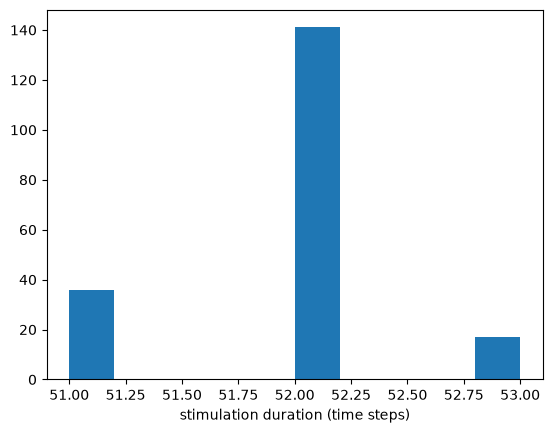

In [5]:
# extraction of onsets and offsets, then test of stimulus duration distribution
cont = True
t = 0
onsets = []
offsets = []
while cont:
    if len(np.argwhere(ts_stim[t+1:]>ts_stim[t])) == 0:
        cont = False
    else:
        next_onset = np.argwhere(ts_stim[t+1:]>ts_stim[t])[0,0] + t + 1
        next_offset = np.argwhere(ts_stim[next_onset+1:]<ts_stim[next_onset])[0,0] + next_onset + 1
        onsets.append(next_onset)
        offsets.append(next_offset)

        t = next_offset

#print(onsets, offsets, sep="\n")
print(len(onsets), len(offsets))

stim_durs = []
for t0, t1 in zip(onsets, offsets):
    stim_durs.append(t1-t0)

plt.hist(stim_durs)
plt.xlabel("stimulation duration (time steps)")

In [6]:
# extraction of epochs for stimulus
stim_epochs = []

for t in onsets:
    stim_epochs.append(ts_stim[t-25:t+125])

stim_epochs = np.array(stim_epochs)
print(stim_epochs.shape)
stim_epochs = stim_epochs.T
print(stim_epochs.shape)

(194, 150)
(150, 194)


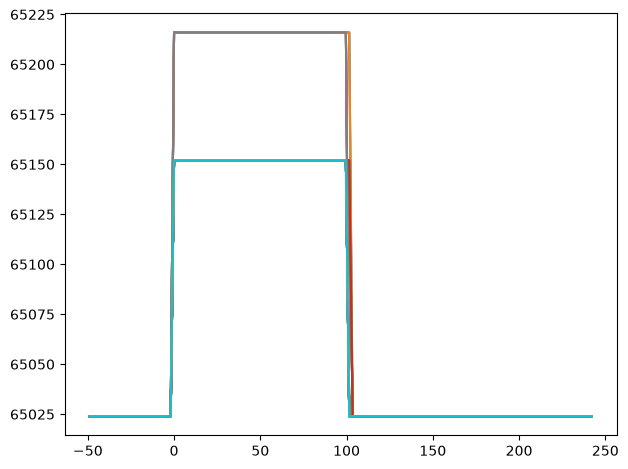

In [7]:
vt = np.arange(-25,125) * 1000.0 / 512.0 # in ms

plt.plot(vt, stim_epochs[:,:50])
plt.tight_layout()

In [8]:
# extraction of epochs for a given channel
i_ch = 3

sensor_epochs = []

for t in onsets:
    sensor_epochs.append(df[i_ch][t-25:t+125])

sensor_epochs = np.array(sensor_epochs)
sensor_epochs = sensor_epochs.T
print(sensor_epochs.shape)

(150, 194)


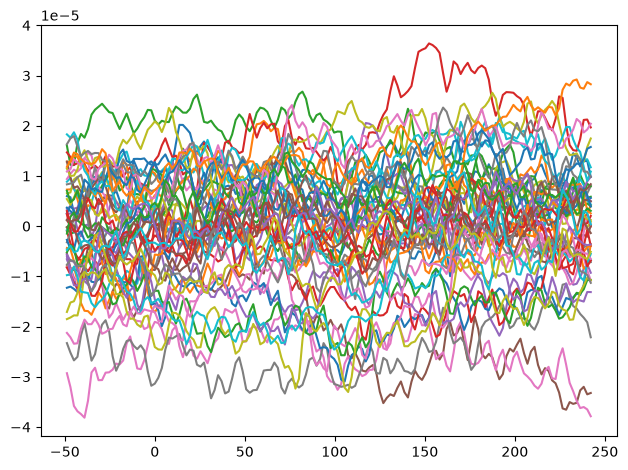

In [9]:
plt.plot(vt, sensor_epochs[:,:50])
plt.tight_layout()

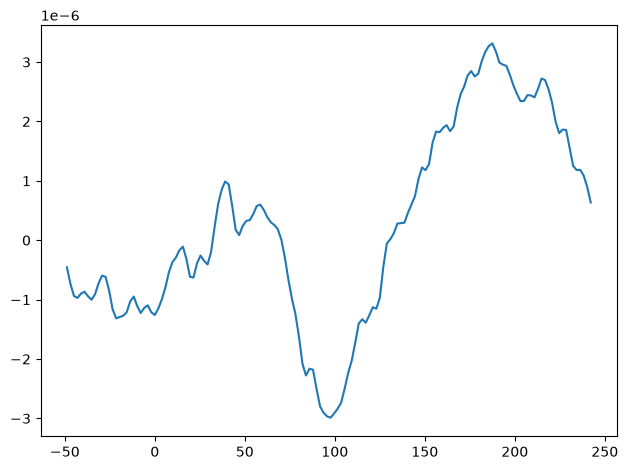

In [10]:
# average response
plt.plot(vt, sensor_epochs[:,:].mean(axis=1))
plt.tight_layout()